In [2]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])

0

C:\Users\Rafi Azka Deandria\AppData\Local\Temp\ipykernel_5940\2129410860.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Rafi Azka Deandria\AppData\Local\Temp\ipykernel_5940\2129410860.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([f"{int(x)} lantai" for x in median_area["stories"]])


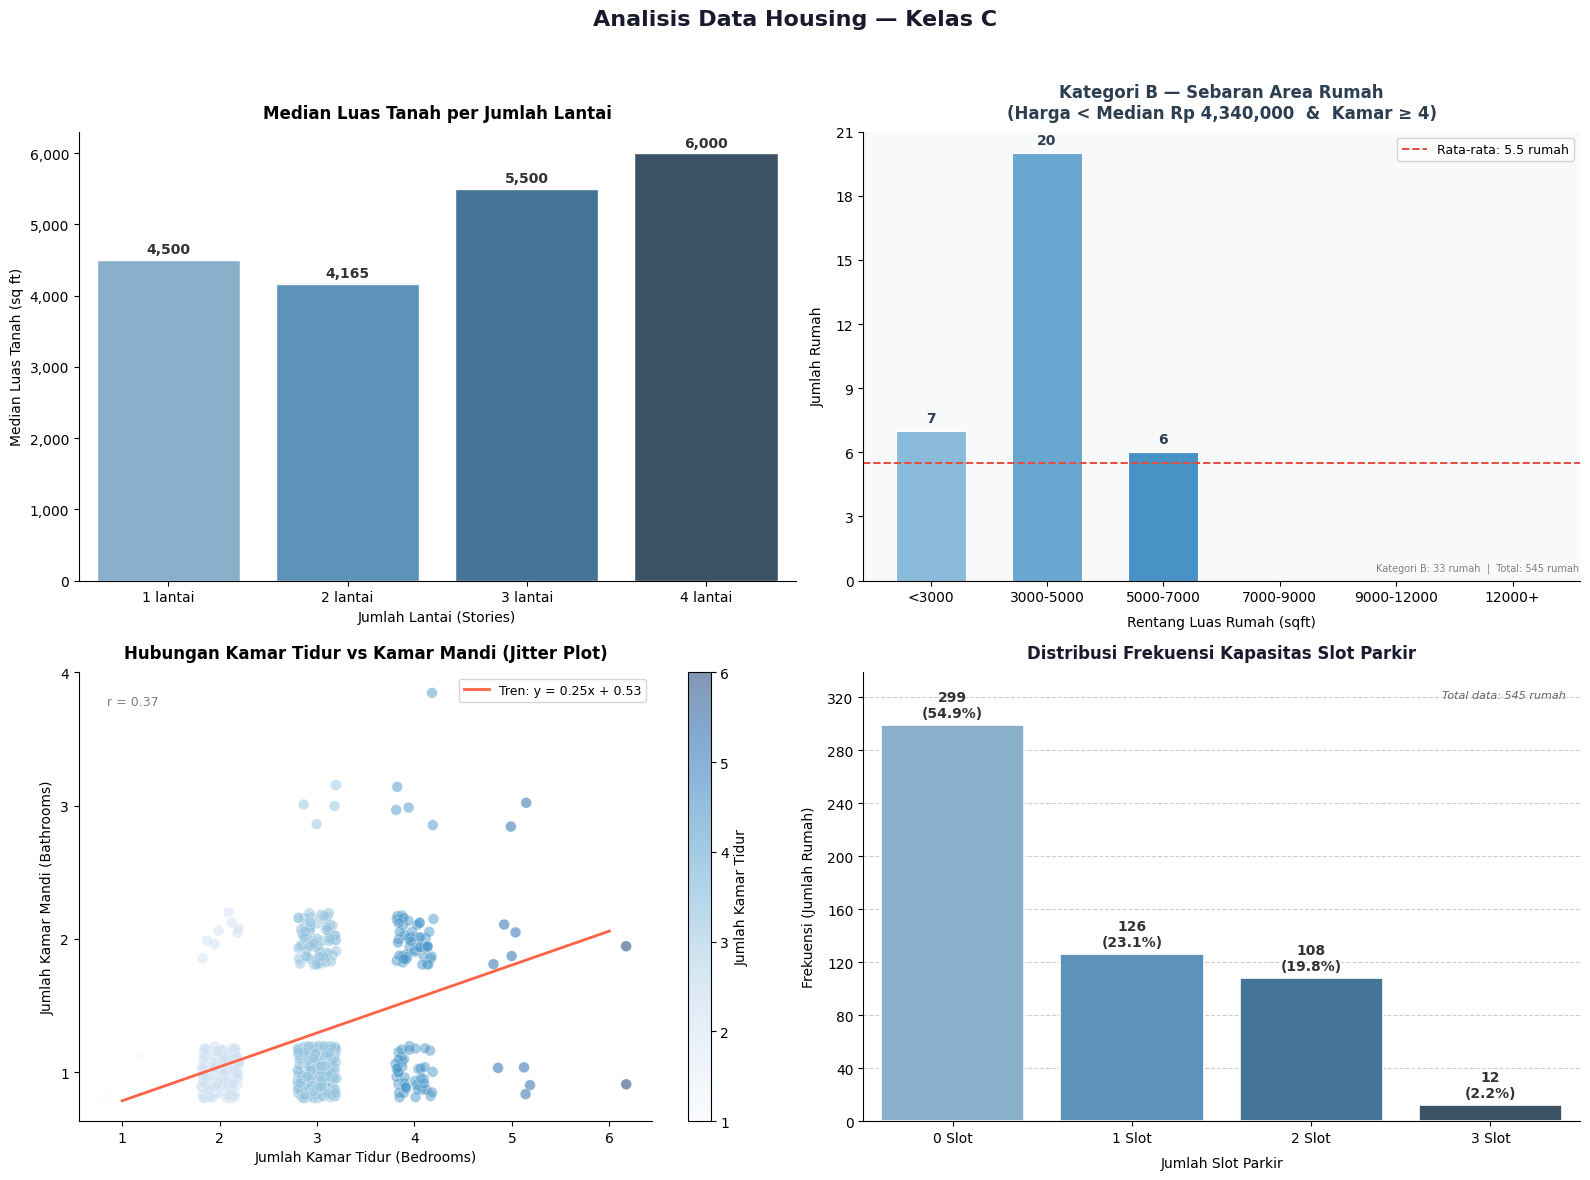

Grafik disimpan: posttest_visualisasi.png


In [4]:
# =============================================================================
#  POSTTEST — ANALISIS DATA HOUSING
#  Kelas C | Kelas C_Housing.csv
#
#  Isi:
#   [1] Median Luas Tanah per Jumlah Lantai          → Bar Chart
#   [2] Sebaran Area Rumah Kategori B                → Bar Chart
#   [3] Hubungan Kamar Tidur vs Kamar Mandi          → Jitter / Scatter Plot
#   [4] Distribusi Frekuensi Slot Parkir             → Countplot
# =============================================================================
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
 
# ─────────────────────────────────────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv("Kelas C_Housing.csv")
 
# Layout: 2×2 grid untuk keempat grafik
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle(
    "Analisis Data Housing — Kelas C",
    fontsize=16, fontweight="bold", y=0.98, color="#1a1a2e"
)
 
# =============================================================================
# [1] MEDIAN LUAS TANAH PER JUMLAH LANTAI — Bar Chart
# =============================================================================
ax1 = axes[0, 0]
 
median_area = (
    df.groupby("stories")["area"]
    .median()
    .reset_index()
    .rename(columns={"area": "median_area"})
    .sort_values("stories")
)
 
sns.barplot(
    data=median_area,
    x="stories",
    y="median_area",
    palette="Blues_d",
    edgecolor="white",
    ax=ax1,
)
 
for bar in ax1.patches:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        h + 50,
        f"{h:,.0f}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold", color="#333333",
    )
 
ax1.set_title("Median Luas Tanah per Jumlah Lantai", fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("Jumlah Lantai (Stories)", fontsize=10)
ax1.set_ylabel("Median Luas Tanah (sq ft)", fontsize=10)
ax1.set_xticklabels([f"{int(x)} lantai" for x in median_area["stories"]])
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
sns.despine(ax=ax1)
 
# =============================================================================
# [2] SEBARAN AREA RUMAH KATEGORI B — Bar Chart
#     Kategori B: harga < median global & bedrooms >= 4
# =============================================================================
ax2 = axes[0, 1]
 
median_price = df["price"].median()
df_b = df[(df["price"] < median_price) & (df["bedrooms"] >= 4)].copy()
 
bins   = [0, 3000, 5000, 7000, 9000, 12000, float("inf")]
labels_area = ["<3000", "3000-5000", "5000-7000", "7000-9000", "9000-12000", "12000+"]
 
df_b["area_range"] = pd.cut(df_b["area"], bins=bins, labels=labels_area, right=True)
 
area_counts = (
    df_b["area_range"]
    .value_counts()
    .reindex(labels_area)
    .fillna(0)
    .astype(int)
    .reset_index()
)
area_counts.columns = ["area_range", "jumlah_rumah"]
 
palette_b = sns.color_palette("Blues_d", n_colors=len(labels_area))
 
bars = ax2.bar(
    area_counts["area_range"],
    area_counts["jumlah_rumah"],
    color=palette_b,
    edgecolor="white",
    linewidth=0.8,
    width=0.6,
)
 
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.3,
            str(int(h)),
            ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#2c3e50",
        )
 
mean_val = area_counts["jumlah_rumah"].mean()
ax2.axhline(
    mean_val,
    color="#e74c3c", linestyle="--", linewidth=1.4,
    label=f"Rata-rata: {mean_val:.1f} rumah",
)
 
ax2.set_title(
    f"Kategori B — Sebaran Area Rumah\n"
    f"(Harga < Median Rp {median_price:,.0f}  &  Kamar ≥ 4)",
    fontsize=12, fontweight="bold", pad=10, color="#2c3e50",
)
ax2.set_xlabel("Rentang Luas Rumah (sqft)", fontsize=10, labelpad=8)
ax2.set_ylabel("Jumlah Rumah", fontsize=10, labelpad=8)
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.legend(fontsize=9)
ax2.set_facecolor("#f8f9fa")
ax2.spines[["top", "right"]].set_visible(False)
 
fig.text(
    0.99, 0.51,
    f"Kategori B: {len(df_b)} rumah  |  Total: {len(df)} rumah",
    ha="right", va="bottom", fontsize=7, color="gray",
)
 
# =============================================================================
# [3] HUBUNGAN KAMAR TIDUR vs KAMAR MANDI — Jitter / Scatter Plot
# =============================================================================
ax3 = axes[1, 0]
 
np.random.seed(42)
jitter_x = df["bedrooms"]  + np.random.uniform(-0.2, 0.2, len(df))
jitter_y = df["bathrooms"] + np.random.uniform(-0.2, 0.2, len(df))
 
sc = ax3.scatter(
    jitter_x, jitter_y,
    alpha=0.5,
    edgecolors="white",
    linewidths=0.4,
    s=60,
    c=df["bedrooms"],
    cmap="Blues",
)
plt.colorbar(sc, ax=ax3, label="Jumlah Kamar Tidur")
 
m, b_coef = np.polyfit(df["bedrooms"], df["bathrooms"], 1)
x_line = np.linspace(df["bedrooms"].min(), df["bedrooms"].max(), 100)
ax3.plot(
    x_line, m * x_line + b_coef,
    color="tomato", linewidth=2,
    label=f"Tren: y = {m:.2f}x + {b_coef:.2f}",
)
 
r = df["bedrooms"].corr(df["bathrooms"])
ax3.text(
    0.05, 0.95, f"r = {r:.2f}",
    transform=ax3.transAxes, fontsize=9,
    va="top", color="gray",
)
 
ax3.set_title("Hubungan Kamar Tidur vs Kamar Mandi (Jitter Plot)", fontsize=12, fontweight="bold", pad=10)
ax3.set_xlabel("Jumlah Kamar Tidur (Bedrooms)", fontsize=10)
ax3.set_ylabel("Jumlah Kamar Mandi (Bathrooms)", fontsize=10)
ax3.set_xticks(sorted(df["bedrooms"].unique()))
ax3.set_yticks(sorted(df["bathrooms"].unique()))
ax3.legend(fontsize=9)
sns.despine(ax=ax3)
 
# =============================================================================
# [4] DISTRIBUSI FREKUENSI SLOT PARKIR — Countplot
# =============================================================================
ax4 = axes[1, 1]
 
parking_counts = df["parking"].value_counts().sort_index()
total = len(df)
 
palette_p = sns.color_palette("Blues_d", n_colors=df["parking"].nunique())
 
sns.countplot(
    data=df,
    x="parking",
    hue="parking",
    palette=palette_p,
    legend=False,
    edgecolor="white",
    linewidth=1.2,
    ax=ax4,
)
 
for bar in ax4.patches:
    slot = int(bar.get_x() + bar.get_width() / 2 + 0.5)
    count = parking_counts.get(slot, 0)
    pct   = count / total * 100
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4,
        f"{count}\n({pct:.1f}%)",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold", color="#333333",
    )
 
ax4.set_title("Distribusi Frekuensi Kapasitas Slot Parkir", fontsize=12, fontweight="bold", pad=10, color="#1a1a2e")
ax4.set_xlabel("Jumlah Slot Parkir", fontsize=10, labelpad=8)
ax4.set_ylabel("Frekuensi (Jumlah Rumah)", fontsize=10, labelpad=8)
ax4.set_xticks([0, 1, 2, 3])
ax4.set_xticklabels(["0 Slot", "1 Slot", "2 Slot", "3 Slot"], fontsize=10)
ax4.set_ylim(0, parking_counts.max() + 40)
ax4.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax4.yaxis.grid(True, linestyle="--", alpha=0.6)
ax4.set_axisbelow(True)
ax4.text(
    0.98, 0.96,
    f"Total data: {total} rumah",
    transform=ax4.transAxes, fontsize=8,
    color="#666666", ha="right", va="top", style="italic",
)
sns.despine(ax=ax4)
 
# =============================================================================
# SIMPAN & TAMPILKAN
# =============================================================================
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("posttest_visualisasi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik disimpan: posttest_visualisasi.png")
 